# Graficar rápido V3 — versión simple

Carga una medición (`Datos/medicionNN`), concatena sus chunks, convierte la posición a
**grados** y grafica **x(t)** e **y(t)** con **líneas verticales** en los instantes en que
se colocan las masas.

Después, para cada **tramo** (entre masas) calcula **período** y **equilibrio** sin asumir
ninguna forma para la señal (no hace falta que sea un coseno):

- **Período**: mediana del tiempo entre cruces de un nivel de referencia *en el mismo sentido*.
- **Equilibrio**: mediana de la señal sobre un número **entero** de ciclos.

Las medianas y el conteo de cruces "netos" hacen que ni el ruido ni los glitches de la cámara
muevan el resultado: no hay filtros, ni envolventes, ni ajustes.

In [3]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# >>> Elegí la medición a graficar (carpeta dentro de Datos) <<<
CARPETA = os.path.join("..", "Datos", "medicion28")

# ---------- leer metadatos ----------
meta = {}
_metas = glob.glob(os.path.join(CARPETA, "*_meta.txt"))
if _metas:
    with open(_metas[0]) as fh:
        for line in fh:
            line = line.strip()
            if "\t" in line and not line.startswith("#"):
                k, v = line.split("\t", 1)
                meta[k] = v

def _mget(clave, cast=float, default=np.nan):
    try:    return cast(meta[clave])
    except Exception: return default

fecha            = meta.get("fecha", "")
dist_pantalla_cm = _mget("distancia_a_la_pantalla (cm)")

# instantes (s) en que se colocó masa -> líneas verticales
masa_times = sorted(float(v) for k, v in meta.items() if re.match(r"masa_\d+_s$", k))

print("medición:", os.path.basename(CARPETA))
print("  fecha            =", fecha)
print("  dist_pantalla_cm =", dist_pantalla_cm)
print("  masa_times (s)   =", masa_times)

# helper: líneas verticales en los instantes de las masas
# def marcar_masas(ax):
#     for i, tm in enumerate(masa_times):
#         ax.axvline(tm, color="red", ls="--", lw=1.2, alpha=0.8,
#                    label=("masa" if i == 0 else None))

medición: medicion28
  fecha            = 2026-06-21T18:06:16
  dist_pantalla_cm = 121.0
  masa_times (s)   = [3076.933333]


In [4]:
# Chunks de datos ordenados por su índice nnnn (excluye el _meta) y concatenados
archivos = glob.glob(os.path.join(CARPETA, "*_[0-9][0-9][0-9][0-9].txt"))
archivos.sort(key=lambda f: int(re.search(r"_(\d+)\.txt$", f).group(1)))
print(f"{len(archivos)} archivos encontrados")

datos = []
for f in archivos:
    a = np.atleast_2d(np.loadtxt(f, delimiter="\t"))
    if a.size:                      # ignora chunks vacíos
        datos.append(a)
datos = np.concatenate(datos, axis=0)

t    = datos[:, 0]   # tiempo (s)
x_mm = datos[:, 1]   # posición X (mm)
y_mm = datos[:, 2]   # posición Y (mm)
rango = t>= 8000
masa_times = [9000, 11400, 12500, 15000]
def marcar_masas(ax):
    for i, tm in enumerate(masa_times):
        ax.axvline(tm, color="red", ls="--", lw=1.2, alpha=0.8,
                   label=("masa" if i == 0 else None))
t, x_mm, y_mm = [arr[rango] for arr in (t, x_mm, y_mm)] 
print("shape:", datos.shape, f"-> {t[-1]:.1f} s de medición")

151 archivos encontrados
shape: (135561, 3) -> 9060.0 s de medición


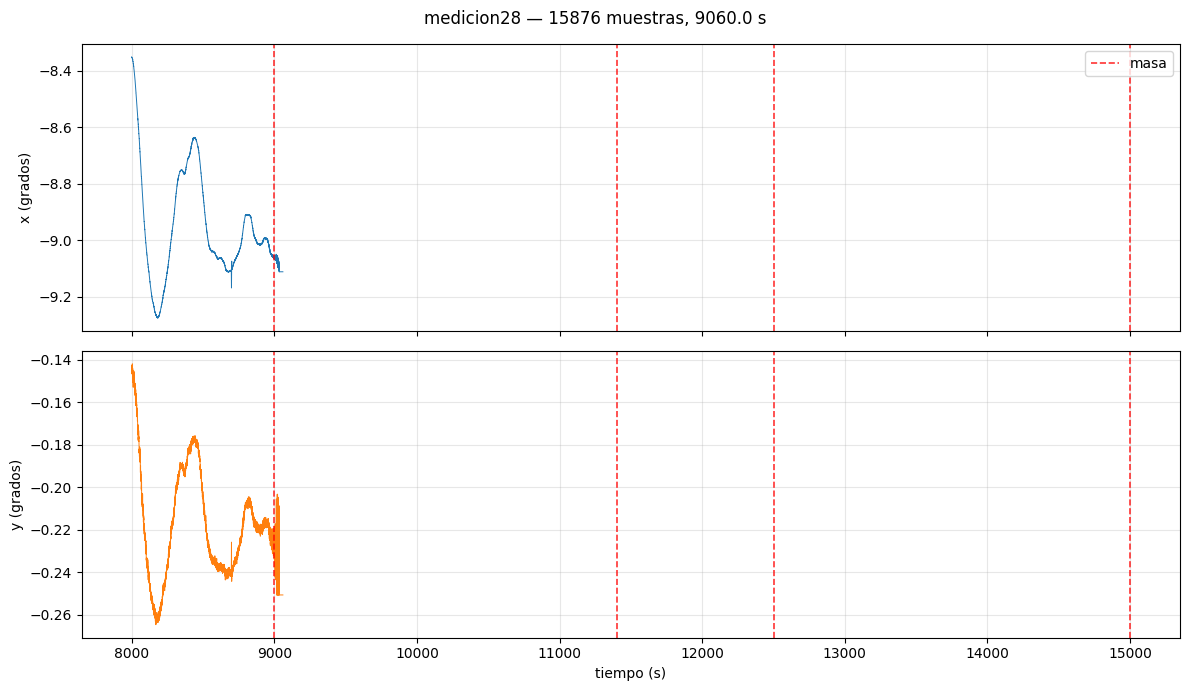

In [5]:
# ---------- mm -> grados (palanca óptica) ----------
# El haz reflejado se desvía 2θ cuando el espejo gira θ -> ángulo del péndulo = haz / 2
FACTOR_ESPEJO = 2.0
if not np.isfinite(dist_pantalla_cm):
    raise ValueError("El meta no tiene 'distancia_a_la_pantalla (cm)'.")
L_mm = dist_pantalla_cm * 10.0   # distancia a la pantalla en mm

def mm_a_grados(v_mm):
    return np.degrees(np.arctan(v_mm / L_mm)) / FACTOR_ESPEJO

x_deg = mm_a_grados(x_mm)
y_deg = mm_a_grados(y_mm)

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axs[0].plot(t, x_deg, lw=0.7)
axs[0].set_ylabel("x (grados)")
axs[1].plot(t, y_deg, lw=0.7, color="tab:orange")
axs[1].set_ylabel("y (grados)")
axs[1].set_xlabel("tiempo (s)")
for ax in axs:
    ax.grid(alpha=0.3)
    marcar_masas(ax)
if masa_times:
    axs[0].legend(loc="upper right")
fig.suptitle(f"{os.path.basename(CARPETA)} — {len(t)} muestras, {t[-1]:.1f} s")
plt.tight_layout()
plt.show()

## Período y equilibrio por tramo (sin asumir la forma de la señal)

La idea, tramo por tramo:

1. **Nivel de referencia**: la mediana del tramo. No importa que quede corrida del equilibrio
   verdadero: solo se usa para detectar cruces.
2. **Cruces**: instantes donde la señal pasa de un lado al otro del nivel. Si el ruido la hace
   cruzar varias veces seguidas, esos cruces (separados menos de `SEP_MIN_S`) se agrupan en
   uno; y un grupo que termina del mismo lado del que empezó (un glitch que va y vuelve)
   se descarta solo.
3. **Período**: una señal que se repite cruza un nivel fijo *en el mismo sentido* una vez por
   ciclo → `T = mediana de las separaciones entre cruces del mismo sentido`. No depende de
   dónde quedó el nivel ni de la forma de la onda.
4. **Equilibrio**: el promedio/mediana solo es insesgado sobre un número **entero** de ciclos.
   Arrancando en el primer cruce (lo que además saltea el transitorio de apoyar la masa) se
   toma la **mediana de cada ciclo** de duración `T`; el equilibrio del tramo es el promedio
   de esas medianas y su desvío estándar da el error (incluye deriva entre ciclos).

**Ojo:** si un tramo no llega a ~1½ períodos no hay dos cruces del mismo sentido: el período
queda `nan` y el equilibrio se reporta como la mediana simple, **avisando que está sesgada**.
La única solución real para eso es medir más tiempo antes de mover la próxima masa.

In [6]:
# ---------- parámetros ----------
SEP_MIN_S = 60.0   # cruces a menos de esto se agrupan como UN cruce (ruido / glitch).
                   # Regla: mucho menor que medio período, mucho mayor que la duración del ruido.

def segmentos(t, masa_times):
    """Bordes (t_ini, t_fin) de cada tramo entre eventos de masa."""
    cortes = [t[0]] + [m for m in masa_times if t[0] < m < t[-1]] + [t[-1]]
    return list(zip(cortes[:-1], cortes[1:]))

def cruces(t, x, nivel, sep_min_s=SEP_MIN_S):
    """Cruces 'netos' de la señal por `nivel`.
    Agrupa cruces múltiples por ruido (separados < sep_min_s) en uno solo y descarta
    los grupos que terminan del mismo lado del que empezaron (glitches).
    Devuelve (tiempos, direcciones), con dirección +1 si sube y -1 si baja."""
    arriba = x > nivel
    i = np.flatnonzero(arriba[1:] != arriba[:-1])        # índices donde cambia de lado
    if len(i) == 0:
        return np.array([]), np.array([], dtype=int)
    grupos = np.split(np.arange(len(i)), np.flatnonzero(np.diff(t[i]) > sep_min_s) + 1)
    tc, dc = [], []
    for g in grupos:
        antes, despues = arriba[i[g[0]]], arriba[i[g[-1]] + 1]
        if antes == despues:                             # glitch: fue y volvió
            continue
        tc.append(float(t[i[g]].mean()))
        dc.append(+1 if despues else -1)
    return np.array(tc), np.array(dc, dtype=int)

def periodo_por_cruces(t_cr, d_cr):
    """T = mediana de las separaciones entre cruces del MISMO sentido (1 por ciclo).
    Devuelve (T, dispersión, cantidad de separaciones usadas)."""
    seps = np.concatenate([np.diff(t_cr[d_cr > 0]), np.diff(t_cr[d_cr < 0])])
    if len(seps) == 0:
        return np.nan, np.nan, 0
    T_err = float(np.std(seps)) if len(seps) > 1 else np.nan
    return float(np.median(seps)), T_err, len(seps)

def equilibrio_por_ciclos(t, x, t0, T):
    """Mediana de la señal en cada ciclo completo [t0 + j·T, t0 + (j+1)·T].
    Devuelve la lista de medianas (vacía si no entra ni un ciclo completo)."""
    eqs = []
    if np.isfinite(T):
        j = 0
        while t0 + (j + 1) * T <= t[-1]:
            m = (t >= t0 + j * T) & (t < t0 + (j + 1) * T)
            if m.sum() > 10:
                eqs.append(float(np.median(x[m])))
            j += 1
    return eqs

In [7]:
print(f"{'tramo':>5} {'t_ini':>8} {'t_fin':>8} | {'T (s)':>15} {'#sep':>5} | {'equilibrio (deg)':>20}")
tramos = []
for k, (ta, tb) in enumerate(segmentos(t, masa_times)):
    m = (t >= ta) & (t <= tb)
    ts, xs = t[m], x_deg[m]
    tramos.append(np.mean(xs))
# corrimiento del equilibrio entre tramos consecutivos (lo que mide Cavendish)
print(tramos)

tramo    t_ini    t_fin |           T (s)  #sep |     equilibrio (deg)
[np.float64(-8.948337709882864), np.float64(-9.087146390061907)]
